# Gompertz fit

In [1]:
# (1) Paths (edit here)
DATA_PATH = "../data/global40.dta"
BASE_ROOT_DIR = "../results/f2_gompertz/decade"
BASE_DIR = BASE_ROOT_DIR

import os
os.makedirs(BASE_DIR, exist_ok=True)

print("DATA_PATH:", DATA_PATH)
print("BASE_DIR :", BASE_DIR)


DATA_PATH: ../data/global40.dta
BASE_DIR : ../results/f2_gompertz/decade


In [2]:
# (2) Dependencies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
from scipy.optimize import minimize
import autograd.numpy as anp
from autograd import grad, hessian

print("OK: imports done.")


OK: imports done.


In [3]:
# (3) Settings
START_AGE   = 50
AGE_MAX     = 100
AGE_STEP    = 1
MIN_N       = 30
MIN_EVENTS  = 10
N_BOOT_RMST = 100
BOOTSTRAP_MIN_SUCCESS = 50
REPORT_AGES = [a for a in [60, 70, 80, 90, 100] if START_AGE <= a <= AGE_MAX]

DECADE_GROUPS = [
    {"label": "≤1919", "start": -np.inf, "end": 1919, "dir": "pre1920"},
    {"label": "1920-1924", "start": 1920, "end": 1924, "dir": "1920_1924"},
    {"label": "1925-1929", "start": 1925, "end": 1929, "dir": "1925_1929"},
    {"label": "1930-1934", "start": 1930, "end": 1934, "dir": "1930_1934"},
    {"label": "1935-1939", "start": 1935, "end": 1939, "dir": "1935_1939"},
    {"label": "1940-1944", "start": 1940, "end": 1944, "dir": "1940_1944"},
    {"label": "1945-1949", "start": 1945, "end": 1949, "dir": "1945_1949"},

]
W_INCH_DOUBLE = 7.0
H_INCH_DOUBLE = 4.0
W_INCH_SINGLE = 3.4
H_INCH_SINGLE = 2.4
DPI_OUT = 600
FONT_SIZE = 9

W_CM = W_INCH_DOUBLE * 2.54
H_CM = H_INCH_DOUBLE * 2.54

AGE_GRID = np.arange(START_AGE, AGE_MAX + 1e-9, AGE_STEP)
T_GRID   = AGE_GRID - START_AGE

print("START_AGE:", START_AGE, "AGE_MAX:", AGE_MAX, "N ages:", len(AGE_GRID))
print("RMST bootstrap replicates:", N_BOOT_RMST)


START_AGE: 50 AGE_MAX: 100 N ages: 51
RMST bootstrap replicates: 100


In [4]:
# (4) Utilities
def trapz(x: np.ndarray, y: np.ndarray) -> float:
    if len(x) < 2 or len(y) < 2:
        return np.nan
    dx = np.diff(x)
    avg_y = (y[:-1] + y[1:]) / 2.0
    return float(np.sum(avg_y * dx))

def find_quantile_age(age: np.ndarray, surv: np.ndarray, p_surv: float = 0.5) -> float:
    if len(age) != len(surv) or np.all(pd.isna(surv)):
        return np.nan
    idx = np.where(surv <= p_surv)[0]
    if len(idx) == 0:
        return np.nan
    i = idx[0]
    if i == 0:
        return float(age[0])
    x1, x2 = age[i - 1], age[i]
    y1, y2 = surv[i - 1], surv[i]
    if np.isnan(y1) or np.isnan(y2) or y1 == y2:
        return float(age[i])
    return float(x1 + (p_surv - y1) * (x2 - x1) / (y2 - y1))

print("OK: utilities ready.")


OK: utilities ready.


In [5]:
# (5) Gompertz model (2 parameters)
# h(t)=lambda*exp(gamma*t); H(t)=(lambda/gamma)*(exp(gamma*t)-1); S(t)=exp(-H(t))

def gompertz_cumhaz(t, gamma, log_lambda):
    lambda_param = anp.exp(log_lambda)
    return (lambda_param / gamma) * anp.expm1(gamma * t)

def gompertz_hazard(t, gamma, log_lambda):
    return anp.exp(log_lambda) * anp.exp(gamma * t)

def gompertz_curves(params: np.ndarray, t_grid: np.ndarray) -> Dict[str, np.ndarray]:
    """Compute Gompertz curves given parameters (gamma, log_lambda) and time grid."""
    gamma, log_lambda = params[0], params[1]
    H = gompertz_cumhaz(t_grid, gamma, log_lambda)
    h = gompertz_hazard(t_grid, gamma, log_lambda)
    S = anp.exp(-H)
    return {"surv": np.asarray(S), "hazard": np.asarray(h), "cumhaz": np.asarray(H), "cdf": np.asarray(1.0 - S)}

def neg_loglik(theta, entry_t, exit_t, event):
    """Negative log-likelihood with left truncation.
    theta = [loglambda, loggamma]
    """
    loglambda, loggamma = theta
    log_lambda = loglambda
    gamma = anp.exp(loggamma)

    H_exit = gompertz_cumhaz(exit_t, gamma, log_lambda)
    H_entry = gompertz_cumhaz(entry_t, gamma, log_lambda)

    logS_exit = -H_exit
    logS_entry = -H_entry

    h_exit = gompertz_hazard(exit_t, gamma, log_lambda)

    return -anp.sum(event * anp.log(h_exit + 1e-12) + logS_exit - logS_entry)

_grad_nll = grad(neg_loglik)
_hess_nll = hessian(neg_loglik)

def fit_gompertz(entry_t, exit_t, event, init=None, maxiter=2000, compute_cov=True):
    if init is None:
        init = np.array([np.log(0.01), np.log(0.01)])

    bounds = [
        (np.log(1e-12), np.log(1.0)),
        (np.log(1e-12), np.log(1.0)),
    ]

    res = minimize(
        fun=lambda th: float(neg_loglik(th, entry_t, exit_t, event)),
        x0=init,
        jac=lambda th: np.asarray(_grad_nll(th, entry_t, exit_t, event)),
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": maxiter},
    )

    theta_hat = res.x
    loglambda, loggamma = theta_hat
    log_lambda = float(loglambda)
    gamma = float(np.exp(loggamma))
    params = np.array([gamma, log_lambda])

    cov_params = None
    if compute_cov:
        cov_theta = None
        try:
            hess = np.asarray(_hess_nll(theta_hat, entry_t, exit_t, event))
            cov_theta = np.linalg.inv(hess)
        except Exception:
            cov_theta = None

        if cov_theta is not None and np.all(np.isfinite(cov_theta)):
            J = np.array([
                [0.0, gamma],
                [1.0, 0.0],
            ])
            cov_params = J @ cov_theta @ J.T

    return params, cov_params, res

def simulate_ci(params: np.ndarray, cov: np.ndarray, t_grid: np.ndarray, n_sim: int = 1000, seed: int = 1):
    """Parametric simulation CI using MVN(params, cov) on (gamma, log_lambda)."""
    if cov is None or np.any(np.isnan(cov)):
        return None
    rng = np.random.default_rng(seed)
    sim = rng.multivariate_normal(mean=params, cov=cov, size=n_sim)

    surv   = np.zeros((n_sim, len(t_grid)))
    haz    = np.zeros_like(surv)
    cumhaz = np.zeros_like(surv)
    cdf    = np.zeros_like(surv)

    for i in range(n_sim):
        curves   = gompertz_curves(sim[i], t_grid)
        surv[i]   = curves["surv"]
        haz[i]    = curves["hazard"]
        cumhaz[i] = curves["cumhaz"]
        cdf[i]    = curves["cdf"]

    def q(x):
        return np.nanpercentile(x, [2.5, 97.5], axis=0)

    return {"surv": q(surv), "hazard": q(haz), "cumhaz": q(cumhaz), "cdf": q(cdf)}

print("OK: Gompertz functions ready.")


OK: Gompertz functions ready.


In [6]:
# (7) Load & clean data
raw = pd.read_stata(DATA_PATH)

raw = (
    raw.assign(
        id=raw["id"].astype(str),
        age=pd.to_numeric(raw["ragey_b"], errors="coerce"),
        rabyear=pd.to_numeric(raw.get("rabyear"), errors="coerce"),
        country=raw["isocountry_c"].astype(str),
        continent=raw["continent_c"].astype(str),
        rwalk1a=pd.to_numeric(raw["rwalk1a"], errors="coerce"),
        ragender=pd.to_numeric(raw.get("ragender"), errors="coerce"),
        rurbrur=pd.to_numeric(raw.get("rurbrur"), errors="coerce"),
        rlung=pd.to_numeric(raw.get("rlung"), errors="coerce"),
        rarthr=pd.to_numeric(raw.get("rarthr"), errors="coerce"),
        rstrok=pd.to_numeric(raw.get("rstrok"), errors="coerce"),
        rheart=pd.to_numeric(raw.get("rheart"), errors="coerce"),
        ralzhe=pd.to_numeric(raw.get("ralzhe"), errors="coerce"),
        rcancr=pd.to_numeric(raw.get("rcancr"), errors="coerce"),
    )
    .loc[:, [
        "id", "age", "rabyear", "country", "continent", "rwalk1a", "ragender", "rurbrur",
        "rlung", "rarthr", "rstrok", "rheart", "ralzhe", "rcancr",
    ]]
    .dropna(subset=["id", "country", "age"])
    .loc[lambda d: d["country"].str.strip() != "", :]
 )

raw["rwalk1a"] = raw["rwalk1a"].where(raw["rwalk1a"].isin([0, 1]))
raw["ragender"] = raw["ragender"].where(raw["ragender"].isin([1, 2]))
raw["rurbrur"] = raw["rurbrur"].where(raw["rurbrur"].isin([0, 1]))

print("raw shape:", raw.shape)
print("countries:", raw["country"].nunique())
print(sorted(raw["country"].astype(str).unique()))
raw.head()


raw shape: (1206788, 14)
countries: 40
['Australia', 'Austria', 'Belgium', 'Brazil', 'Bulgaria', 'China', 'Costa Rica', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'England', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'India', 'Ireland', 'Israel', 'Italy', 'Japan', 'Korea', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Mexico', 'Netherlands', 'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'South Africa', 'Spain', 'Sweden', 'Switzerland', 'USA']


,id,age,rabyear,country,continent,rwalk1a,ragender,rurbrur,rlung,rarthr,rstrok,rheart,ralzhe,rcancr
0,1.0,73.0,1919.0,Australia,Oceania,0.0,NaN,1.0,NaN,0.0,0.0,1.0,NaN,0.0
1,1.0,75.0,1919.0,Australia,Oceania,1.0,NaN,NaN,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,75.0,1919.0,Australia,Oceania,1.0,NaN,1.0,0.0,0.0,0.0,0.0,NaN,1.0
3,1.0,77.0,1919.0,Australia,Oceania,1.0,NaN,NaN,0.0,0.0,0.0,1.0,NaN,0.0
4,2.0,73.0,1919.0,Australia,Oceania,0.0,NaN,1.0,NaN,0.0,0.0,0.0,NaN,0.0


In [7]:
# (8) Build person-level data
processed_parquet = os.path.join(os.path.dirname(DATA_PATH), "person_left_trunc_birthyear.parquet")
processed_csv = os.path.join(os.path.dirname(DATA_PATH), "person_left_trunc_birthyear.csv")

if os.path.exists(processed_parquet):
    print("Found parquet, trying to load:", processed_parquet)
    try:
        person = pd.read_parquet(processed_parquet)
        print("Loaded parquet file.")
    except Exception as e:
        print("Warning: failed to read parquet (pyarrow/fastparquet may be missing); falling back to CSV. Error:", str(e))
        if os.path.exists(processed_csv):
            person = pd.read_csv(processed_csv)
            print("Loaded CSV file.")
        else:
            print("No CSV available; will build from raw data.")
            person = None
elif os.path.exists(processed_csv):
    print("Loading preprocessed CSV:", processed_csv)
    person = pd.read_csv(processed_csv)
else:
    person = None

if person is not None:
    required = {"country", "id", "rabyear"}
    missing = required - set(person.columns)
    if missing:
        print("Preprocessed person file missing columns:", sorted(missing))
        print("Rebuilding person-level data from raw.")
        person = None

if person is None:
    print("Preprocessed file not found — building person-level data from raw.")

    person_rows: List[Dict] = []

    for (country, pid), g in raw.sort_values(["country", "id", "age"]).groupby(["country", "id"]):
        cont = g["continent"].dropna().iloc[0] if g["continent"].notna().any() else np.nan
        rabyear = pd.to_numeric(g["rabyear"], errors="coerce").dropna()
        rabyear = float(rabyear.iloc[0]) if not rabyear.empty else np.nan

        valid = g.loc[g["rwalk1a"].notna(), :]
        if valid.empty:
            continue

        baseline_valid_age = valid["age"].min()
        baseline_state     = valid.iloc[0]["rwalk1a"]
        censor_age         = valid["age"].max()
        event_age          = valid.loc[valid["rwalk1a"] == 1, "age"].min() if (valid["rwalk1a"] == 1).any() else np.nan

        if pd.isna(baseline_state) or baseline_state != 0:
            continue
        if pd.isna(baseline_valid_age) or pd.isna(censor_age) or censor_age <= baseline_valid_age:
            continue
        if censor_age <= START_AGE:
            continue

        censor_age_w = min(censor_age, AGE_MAX)
        event_w      = 1 if (not pd.isna(event_age) and event_age <= AGE_MAX) else 0
        exit_age     = event_age if event_w == 1 else censor_age_w

        entry_age = min(max(baseline_valid_age, START_AGE), AGE_MAX)
        exit_age  = min(exit_age, AGE_MAX)

        entry_t = entry_age - START_AGE
        exit_t  = exit_age  - START_AGE

        if pd.isna(entry_t) or pd.isna(exit_t) or exit_t <= entry_t:
            continue

        person_rows.append(dict(
            country=str(country),
            continent=str(cont),
            id=str(pid),
            rabyear=rabyear,
            entry_age=entry_age,
            exit_age=exit_age,
            entry_t=entry_t,
            exit_t=exit_t,
            event_w=event_w,
            baseline_valid_age=baseline_valid_age,
        ))

    person = pd.DataFrame(person_rows)

    os.makedirs(os.path.dirname(processed_csv), exist_ok=True)
    try:
        print(f"Saving parquet to: {processed_parquet}")
        person.to_parquet(processed_parquet, index=False)
    except Exception:
        print("Warning: parquet write failed (pyarrow/fastparquet may be missing). Saving CSV instead and advising install.")
        print("To enable parquet support, install pyarrow: pip install pyarrow")
        print(f"Saving csv to: {processed_csv}")
        person.to_csv(processed_csv, index=False)
    else:
        print(f"Saving csv to: {processed_csv}")
        person.to_csv(processed_csv, index=False)

print("person rows:", person.shape[0])
person.head()


Loading preprocessed CSV: ../data/person_left_trunc_birthyear.csv
person rows: 193731


,country,continent,id,rabyear,entry_age,exit_age,entry_t,exit_t,event_w,baseline_valid_age
0,Australia,Oceania,1.0,1919.0,73.0,75.0,23.0,25.0,1,73.0
1,Australia,Oceania,10.0,1912.0,80.0,82.0,30.0,32.0,0,80.0
2,Australia,Oceania,100.0,1926.0,66.0,78.0,16.0,28.0,1,66.0
3,Australia,Oceania,1000.0,1912.0,80.0,82.0,30.0,32.0,0,80.0
4,Australia,Oceania,1001.0,1911.0,81.0,85.0,31.0,35.0,0,81.0


In [8]:
# Check countries used in fit (MIN_N/MIN_EVENTS)
countries_raw = sorted(raw["country"].dropna().astype(str).str.strip().unique().tolist())
by_cty = (
    person.groupby("country", dropna=False)
    .agg(n=("event_w", "size"), events=("event_w", "sum"))
    .reset_index()
 )
by_cty["country"] = by_cty["country"].astype(str).str.strip()
used = by_cty.loc[(by_cty["n"] >= MIN_N) & (by_cty["events"] >= MIN_EVENTS), "country"].tolist()
used_set = set(used)
not_used = [c for c in countries_raw if c not in used_set]
print("Countries used in fit:", len(used))
print("Countries not used:", not_used)

Countries used in fit: 36
Countries not used: ['Brazil', 'Costa Rica', 'Ireland', 'South Africa']


In [9]:
# (13) Run decade Gompertz fits and export CSV estimate tables only
import zlib


def _filter_decade(df: pd.DataFrame, start: float, end: float) -> pd.DataFrame:
    out = df.copy()
    out["rabyear"] = pd.to_numeric(out["rabyear"], errors="coerce")
    if np.isfinite(start):
        out = out.loc[out["rabyear"] >= start]
    if np.isfinite(end):
        out = out.loc[out["rabyear"] <= end]
    return out


def _stable_seed(*parts) -> int:
    key = "|".join(str(p) for p in parts)
    return int(zlib.adler32(key.encode("utf-8")) & 0xFFFFFFFF)


def _rmst_from_params(params: np.ndarray) -> float:
    curves = gompertz_curves(params, T_GRID)
    surv_vals = np.clip(curves["surv"], 0, 1)
    return START_AGE + trapz(T_GRID, surv_vals)


def _bootstrap_rmst_ci(
    df_fit: pd.DataFrame,
    init_params: np.ndarray,
    seed: int,
    n_boot: int = N_BOOT_RMST,
    min_success: int = BOOTSTRAP_MIN_SUCCESS,
) -> tuple:
    """Person-level nonparametric bootstrap CI for RMST."""
    if n_boot <= 0 or df_fit.empty:
        return np.nan, np.nan, 0

    rng = np.random.default_rng(seed)
    boot_rmst = []
    base = df_fit[["entry_t", "exit_t", "event_w"]].to_numpy()
    n = base.shape[0]
    init_theta = np.array([init_params[1], np.log(init_params[0])])

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        sample = base[idx, :]
        event_b = sample[:, 2].astype(int)
        if event_b.sum() < MIN_EVENTS:
            continue
        try:
            params_b, _, res_b = fit_gompertz(
                sample[:, 0].astype(float),
                sample[:, 1].astype(float),
                event_b,
                init=init_theta,
                maxiter=500,
                compute_cov=False,
            )
            if not bool(getattr(res_b, "success", True)):
                continue
            rmst_b = _rmst_from_params(params_b)
            if np.isfinite(rmst_b):
                boot_rmst.append(float(rmst_b))
        except Exception:
            continue

    if len(boot_rmst) < min_success:
        return np.nan, np.nan, len(boot_rmst)

    lcl, ucl = np.nanpercentile(boot_rmst, [2.5, 97.5])
    return float(lcl), float(ucl), len(boot_rmst)


def _fit_summary(df_fit: pd.DataFrame, decade: dict, geography_type: str, country: str, continent: str) -> dict:
    df_fit = df_fit.dropna(subset=["entry_t", "exit_t", "event_w"])
    n = int(len(df_fit))
    events = int(df_fit["event_w"].sum())
    censored = int(n - events)

    base = {
        "decade": decade["label"],
        "decade_start": decade["start"] if np.isfinite(decade["start"]) else np.nan,
        "decade_end": decade["end"] if np.isfinite(decade["end"]) else np.nan,
        "geography_type": geography_type,
        "country": country,
        "continent": continent,
        "n": n,
        "events": events,
        "censored": censored,
    }

    if n < MIN_N or events < MIN_EVENTS:
        return {
            **base,
            "fit_ok": False,
            "fit_message": f"Skipped: n={n}, events={events}",
            "rmst": np.nan,
            "rmst_lcl": np.nan,
            "rmst_ucl": np.nan,
            "lambda_est": np.nan,
            "lambda_se": np.nan,
            "lambda_lcl": np.nan,
            "lambda_ucl": np.nan,
            "gamma_est": np.nan,
            "gamma_se": np.nan,
            "gamma_lcl": np.nan,
            "gamma_ucl": np.nan,
        }

    try:
        entry_t = df_fit["entry_t"].to_numpy(dtype=float)
        exit_t = df_fit["exit_t"].to_numpy(dtype=float)
        event = df_fit["event_w"].to_numpy(dtype=int)
        params, cov, res = fit_gompertz(entry_t, exit_t, event)
        gamma, log_lambda = params
        lambda_est = float(np.exp(log_lambda))

        rmst = _rmst_from_params(params)
        rmst_lcl, rmst_ucl, rmst_boot_success = _bootstrap_rmst_ci(
            df_fit,
            params,
            seed=_stable_seed(decade["label"], geography_type, country, "rmst_bootstrap"),
        )

        if cov is not None and np.all(np.isfinite(cov)):
            gamma_se = float(np.sqrt(cov[0, 0]))
            log_lambda_se = float(np.sqrt(cov[1, 1]))
            lambda_se = float(lambda_est * log_lambda_se)
            gamma_lcl = float(gamma - 1.96 * gamma_se)
            gamma_ucl = float(gamma + 1.96 * gamma_se)
            lambda_lcl = float(np.exp(log_lambda - 1.96 * log_lambda_se))
            lambda_ucl = float(np.exp(log_lambda + 1.96 * log_lambda_se))
        else:
            gamma_se = log_lambda_se = lambda_se = np.nan
            gamma_lcl = gamma_ucl = lambda_lcl = lambda_ucl = np.nan

        return {
            **base,
            "fit_ok": bool(getattr(res, "success", True)),
            "fit_message": f"{str(getattr(res, 'message', ''))}; rmst_boot_success={rmst_boot_success}",
            "rmst": float(rmst),
            "rmst_lcl": rmst_lcl,
            "rmst_ucl": rmst_ucl,
            "lambda_est": lambda_est,
            "lambda_se": lambda_se,
            "lambda_lcl": lambda_lcl,
            "lambda_ucl": lambda_ucl,
            "gamma_est": float(gamma),
            "gamma_se": gamma_se,
            "gamma_lcl": gamma_lcl,
            "gamma_ucl": gamma_ucl,
        }
    except Exception as ex:
        return {
            **base,
            "fit_ok": False,
            "fit_message": str(ex),
            "rmst": np.nan,
            "rmst_lcl": np.nan,
            "rmst_ucl": np.nan,
            "lambda_est": np.nan,
            "lambda_se": np.nan,
            "lambda_lcl": np.nan,
            "lambda_ucl": np.nan,
            "gamma_est": np.nan,
            "gamma_se": np.nan,
            "gamma_lcl": np.nan,
            "gamma_ucl": np.nan,
        }


if "person" not in globals() or person is None or person.empty:
    raise RuntimeError("person is empty. Run the person-level build cell first.")

all_rows = []
for decade in DECADE_GROUPS:
    person_dec = _filter_decade(person, decade["start"], decade["end"])
    print(f"Decade {decade['label']}: {len(person_dec):,} people")

    all_rows.append(_fit_summary(person_dec, decade, "Global", "Global", "Global"))

    for country in sorted(person_dec["country"].dropna().astype(str).unique()):
        df_cty = person_dec.loc[person_dec["country"].astype(str) == country].copy()
        continent = (
            df_cty["continent"].dropna().astype(str).iloc[0]
            if "continent" in df_cty.columns and df_cty["continent"].notna().any()
            else "Unknown"
        )
        all_rows.append(_fit_summary(df_cty, decade, "Country", country, continent))

estimate_cols = [
    "decade", "decade_start", "decade_end", "geography_type", "country", "continent",
    "n", "events", "censored", "fit_ok", "fit_message",
    "rmst", "rmst_lcl", "rmst_ucl",
    "lambda_est", "lambda_se", "lambda_lcl", "lambda_ucl",
    "gamma_est", "gamma_se", "gamma_lcl", "gamma_ucl",
]

decade_estimates = pd.DataFrame(all_rows)
decade_estimates = decade_estimates.reindex(columns=estimate_cols)
decade_estimates = decade_estimates.sort_values(["decade_start", "geography_type", "country"], na_position="first")

global_path = os.path.join(BASE_DIR, "gompertz_decade_global_estimates.csv")
country_path = os.path.join(BASE_DIR, "gompertz_decade_country_estimates.csv")

estimate_output = decade_estimates.loc[decade_estimates["fit_ok"]].copy()
global_estimates = estimate_output.loc[estimate_output["geography_type"] == "Global"].copy()
country_estimates = estimate_output.loc[estimate_output["geography_type"] == "Country"].copy()

global_estimates.to_csv(global_path, index=False)
country_estimates.to_csv(country_path, index=False)

print("Saved:", global_path)
print("Saved:", country_path)
print("Successful fits:", len(estimate_output), "of", len(decade_estimates))
estimate_output.head(10)


Decade ≤1919: 5,651 people


Decade 1920-1924: 5,717 people


Decade 1925-1929: 8,955 people


Decade 1930-1934: 13,900 people


Decade 1935-1939: 19,884 people


Decade 1940-1944: 23,719 people


Decade 1945-1949: 29,283 people


Saved: ../results/f2_gompertz/decade/gompertz_decade_global_estimates.csv
Saved: ../results/f2_gompertz/decade/gompertz_decade_country_estimates.csv
Successful fits: 198 of 238


,decade,decade_start,decade_end,geography_type,country,continent,n,events,censored,fit_ok,...,rmst_lcl,rmst_ucl,lambda_est,lambda_se,lambda_lcl,lambda_ucl,gamma_est,gamma_se,gamma_lcl,gamma_ucl
1,≤1919,NaN,1919,Country,Australia,Oceania,1036,614,422,True,...,74.612130,78.855577,5.824769e-03,1.524149e-03,3.487734e-03,9.727786e-03,0.086862,0.007385,0.072387,0.101337
3,≤1919,NaN,1919,Country,Belgium,Europe,34,15,19,True,...,80.705652,94.806261,6.696610e-05,2.068870e-04,1.570652e-07,2.855157e-02,0.177291,0.070288,0.039526,0.315056
6,≤1919,NaN,1919,Country,Denmark,Europe,42,16,26,True,...,87.607659,96.060579,6.939321e-06,2.028817e-05,2.252437e-08,2.137870e-03,0.223070,0.066772,0.092196,0.353944
7,≤1919,NaN,1919,Country,England,Europe,301,169,132,True,...,88.911590,89.249167,1.000000e-12,2.239861e-12,1.239915e-14,8.065070e-11,0.682873,0.058142,0.568915,0.796832
9,≤1919,NaN,1919,Country,France,Europe,36,18,18,True,...,61.343246,94.799703,5.765891e-04,1.705110e-03,1.752329e-06,1.897217e-01,0.129429,0.068910,-0.005635,0.264494
14,≤1919,NaN,1919,Country,Japan,Asia,896,317,579,True,...,81.986371,83.564438,7.877146e-04,2.574998e-04,4.150596e-04,1.494952e-03,0.142522,0.010401,0.122136,0.162908
15,≤1919,NaN,1919,Country,Korea,Asia,71,53,18,True,...,76.764683,90.742557,4.730830e-04,8.532456e-04,1.379414e-05,1.622483e-02,0.142212,0.041969,0.059952,0.224472
17,≤1919,NaN,1919,Country,Mexico,North America,180,58,122,True,...,68.821409,87.040316,5.897291e-03,7.004732e-03,5.748930e-04,6.049481e-02,0.069947,0.029795,0.011548,0.128345
21,≤1919,NaN,1919,Country,Spain,Europe,57,25,32,True,...,71.711486,94.103082,4.263281e-04,9.532862e-04,5.325856e-06,3.412703e-02,0.129213,0.051986,0.027320,0.231105
22,≤1919,NaN,1919,Country,Sweden,Europe,68,23,45,True,...,78.486855,94.939038,7.273513e-05,1.803022e-04,5.645112e-07,9.371646e-03,0.168684,0.057854,0.055291,0.282077


## RMST decade point-line plots

Saved: ../results/f2_gompertz/decade/gompertz_decade_global_equalweight_estimates.csv
Saved: ../results/f2_gompertz/decade/gompertz_decade_global_popweight_estimates.csv


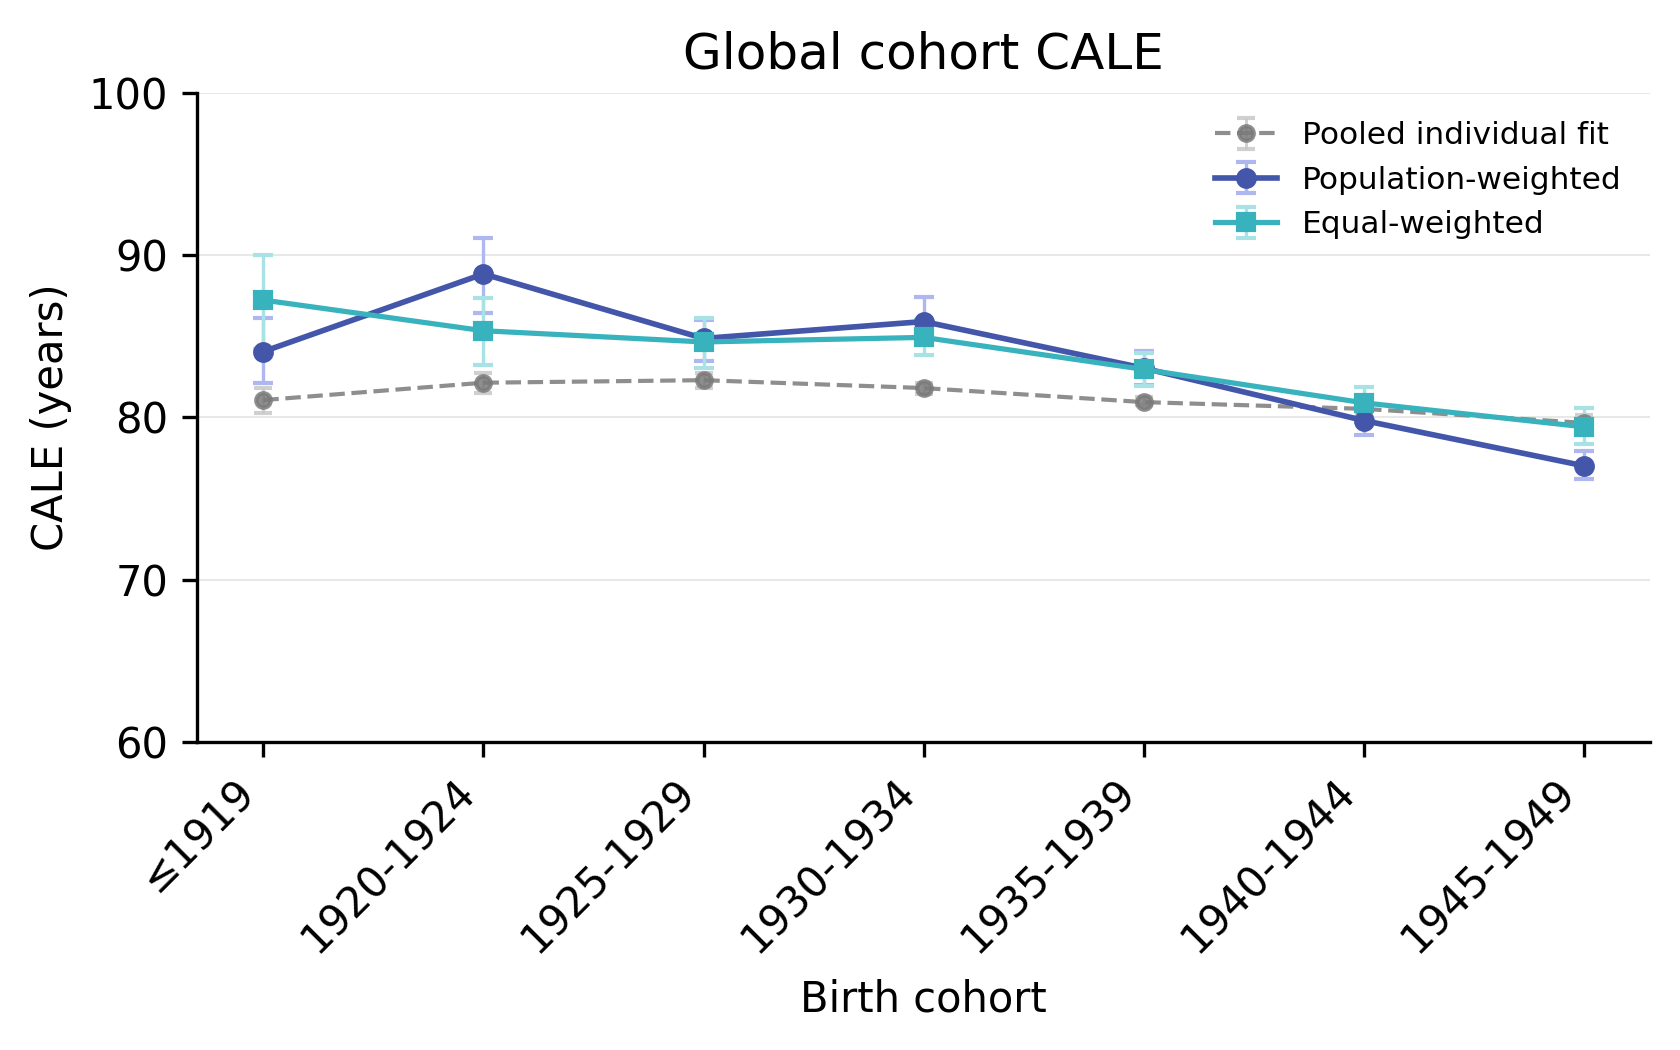

Saved: ../results/f2_gompertz/decade/gompertz_decade_global_rmst.pdf


Saved: ../results/f2_gompertz/decade/gompertz_decade_country_rmst_6x6.pdf
Countries plotted: 36


In [10]:
# (14) Plot RMST by decade: global and country 6x6 panels
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

PLOT_YMIN = 60
PLOT_YMAX = 100
PLOT_YTICKS = np.arange(60, 101, 10)

GLOBAL_EST_PATH = os.path.join(BASE_DIR, "gompertz_decade_global_estimates.csv")
COUNTRY_EST_PATH = os.path.join(BASE_DIR, "gompertz_decade_country_estimates.csv")
GLOBAL_RMST_PDF = os.path.join(BASE_DIR, "gompertz_decade_global_rmst.pdf")
COUNTRY_RMST_PDF = os.path.join(BASE_DIR, "gompertz_decade_country_rmst_6x6.pdf")
GLOBAL_EQUALWEIGHT_PATH = os.path.join(BASE_DIR, "gompertz_decade_global_equalweight_estimates.csv")
GLOBAL_POPWEIGHT_PATH = os.path.join(BASE_DIR, "gompertz_decade_global_popweight_estimates.csv")

global_plot = pd.read_csv(GLOBAL_EST_PATH)
country_plot = pd.read_csv(COUNTRY_EST_PATH)

continent_palette = {
    "Europe": "#F29471",
    "Asia": "#E45781",
    "North America": "#B279D8",
    "Oceania": "#3E83C7",
}


def _lighten_hex(hex_color: str, amount: float = 0.78) -> str:
    """Blend a hex color with white for title label backgrounds."""
    hex_color = str(hex_color).strip().lstrip("#")
    if len(hex_color) != 6:
        return "#F0F0F0"
    rgb = np.array([int(hex_color[i:i+2], 16) for i in (0, 2, 4)], dtype=float)
    out = rgb + (255 - rgb) * amount
    return "#" + "".join(f"{int(round(v)):02X}" for v in out)

# Use the configured decade order so missing country estimates leave gaps naturally.
decade_order = [d["label"] for d in DECADE_GROUPS]
decade_pos = {label: i for i, label in enumerate(decade_order)}

def _prep_plot_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out = out.loc[out["fit_ok"].astype(bool)].copy() if "fit_ok" in out.columns else out.copy()
    out["decade"] = pd.Categorical(out["decade"], categories=decade_order, ordered=True)
    out["x"] = out["decade"].astype(str).map(decade_pos)
    out = out.dropna(subset=["x", "rmst"]).sort_values("x")
    out["x"] = out["x"].astype(float)
    return out

def _rmst_yerr(df: pd.DataFrame):
    if {"rmst_lcl", "rmst_ucl"}.issubset(df.columns):
        lower = (df["rmst"] - df["rmst_lcl"]).clip(lower=0)
        upper = (df["rmst_ucl"] - df["rmst"]).clip(lower=0)
        if lower.notna().any() and upper.notna().any():
            return np.vstack([lower.fillna(0).to_numpy(), upper.fillna(0).to_numpy()])
    return None

def _format_decade_axis(ax):
    ax.set_ylim(PLOT_YMIN, PLOT_YMAX)
    ax.set_yticks(PLOT_YTICKS)
    ax.set_xticks(range(len(decade_order)))
    ax.set_xticklabels(decade_order, rotation=45, ha="right")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", color="#DDDDDD", linewidth=0.4, alpha=0.8)


def _load_population_weights_for_decade(countries):
    iso_path = os.path.join(os.path.dirname(DATA_PATH), "iso40.csv")
    pop_path = os.path.join(os.path.dirname(DATA_PATH), "wb", "wb_2019_2024.csv")
    if not os.path.exists(iso_path) or not os.path.exists(pop_path):
        print("Population weights unavailable; missing:", iso_path, pop_path)
        return {}, pd.DataFrame()

    iso = pd.read_csv(iso_path)
    iso["isocountry_c"] = iso["isocountry_c"].astype(str).str.strip().str.lower()
    iso["iso3c"] = iso["iso3c"].astype(str).str.strip().str.upper()
    iso_map = dict(zip(iso["isocountry_c"], iso["iso3c"]))

    pop = pd.read_csv(pop_path)
    pop["iso3"] = pop["iso3"].astype(str).str.strip().str.upper()
    pop["date"] = pd.to_numeric(pop["date"], errors="coerce")
    pop["total_population"] = pd.to_numeric(pop["total_population"], errors="coerce")
    pop = pop.dropna(subset=["iso3", "date", "total_population"])
    pop_latest = pop.sort_values("date").groupby("iso3", as_index=False).tail(1)

    rows = []
    missing = []
    for country in countries:
        iso3 = iso_map.get(str(country).strip().lower(), "")
        if not iso3:
            missing.append(country)
            continue
        prow = pop_latest.loc[pop_latest["iso3"] == iso3]
        if prow.empty:
            missing.append(country)
            continue
        rows.append({
            "country": country,
            "iso3": iso3,
            "year": int(prow.iloc[0]["date"]),
            "population": float(prow.iloc[0]["total_population"]),
        })
    if missing:
        print("Missing population weights for:", missing)
    if not rows:
        return {}, pd.DataFrame()
    out = pd.DataFrame(rows)
    out["weight"] = out["population"] / out["population"].sum()
    return dict(zip(out["country"], out["weight"])), out


def _weighted_rmst_summary(values, weights, B=2000, seed=20240512):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mask = np.isfinite(values) & np.isfinite(weights) & (weights >= 0)
    values = values[mask]
    weights = weights[mask]
    if values.size == 0:
        return np.nan, np.nan, np.nan
    weights = weights / weights.sum() if weights.sum() > 0 else np.ones(values.size) / values.size
    est = float(np.sum(values * weights))
    if values.size == 1:
        return est, est, est
    rng = np.random.default_rng(seed)
    boot = np.full(B, np.nan)
    idx_all = np.arange(values.size)
    for b in range(B):
        idx = rng.choice(idx_all, size=values.size, replace=True, p=weights)
        boot[b] = float(np.mean(values[idx]))
    lcl, ucl = np.nanpercentile(boot, [2.5, 97.5])
    return est, float(lcl), float(ucl)


def _build_global_weighted_decade_estimates(country_df, weighting="equal", pop_weight_map=None):
    rows = []
    fit_df = country_df.copy()
    fit_df = fit_df.loc[fit_df["fit_ok"].astype(bool)].copy() if "fit_ok" in fit_df.columns else fit_df.copy()
    fit_df = fit_df.dropna(subset=["country", "decade", "rmst"])
    for d_idx, decade in enumerate(decade_order):
        sub = fit_df.loc[fit_df["decade"].astype(str).eq(str(decade))].copy()
        if sub.empty:
            continue
        if weighting == "population":
            sub["weight"] = sub["country"].map(pop_weight_map or {})
            sub = sub.dropna(subset=["weight"])
            label = "population-weighted"
        else:
            sub["weight"] = 1.0
            label = "equal-weighted"
        if sub.empty:
            continue
        est, lcl, ucl = _weighted_rmst_summary(sub["rmst"], sub["weight"], seed=20240512 + d_idx + (100 if weighting == "population" else 0))
        rows.append({
            "decade": decade,
            "decade_start": sub["decade_start"].dropna().iloc[0] if sub["decade_start"].notna().any() else np.nan,
            "decade_end": sub["decade_end"].dropna().iloc[0] if sub["decade_end"].notna().any() else np.nan,
            "geography_type": "Global",
            "country": "Global",
            "continent": "Global",
            "weighting": label,
            "n": int(sub["n"].sum()) if "n" in sub.columns else len(sub),
            "events": int(sub["events"].sum()) if "events" in sub.columns else np.nan,
            "censored": int(sub["censored"].sum()) if "censored" in sub.columns else np.nan,
            "fit_ok": True,
            "fit_message": f"country-level RMST aggregated; {label}",
            "rmst": est,
            "rmst_lcl": lcl,
            "rmst_ucl": ucl,
            "n_countries": int(sub["country"].nunique()),
        })
    return pd.DataFrame(rows)

country_names_for_weights = sorted(country_plot["country"].dropna().astype(str).unique())
pop_weight_map_decade, pop_weight_report_decade = _load_population_weights_for_decade(country_names_for_weights)
global_equalweight_plot = _build_global_weighted_decade_estimates(country_plot, weighting="equal")
global_popweight_plot = _build_global_weighted_decade_estimates(country_plot, weighting="population", pop_weight_map=pop_weight_map_decade)
if not global_equalweight_plot.empty:
    global_equalweight_plot.to_csv(GLOBAL_EQUALWEIGHT_PATH, index=False)
    print("Saved:", GLOBAL_EQUALWEIGHT_PATH)
if not global_popweight_plot.empty:
    global_popweight_plot.to_csv(GLOBAL_POPWEIGHT_PATH, index=False)
    print("Saved:", GLOBAL_POPWEIGHT_PATH)

# Global single-panel plot
gdf = _prep_plot_df(global_plot)
gdf_eq = _prep_plot_df(global_equalweight_plot) if not global_equalweight_plot.empty else pd.DataFrame()
gdf_pop = _prep_plot_df(global_popweight_plot) if not global_popweight_plot.empty else pd.DataFrame()
fig, ax = plt.subplots(figsize=(5.7, 3.6), dpi=300)
if not gdf.empty:
    ax.errorbar(
        gdf["x"],
        gdf["rmst"],
        yerr=_rmst_yerr(gdf),
        fmt="o--",
        color="#7A7A7A",
        ecolor="#C8C8C8",
        elinewidth=0.7,
        capsize=2.2,
        markersize=3.5,
        linewidth=1.0,
        alpha=0.85,
        label="Pooled individual fit",
    )
if not gdf_pop.empty:
    ax.errorbar(
        gdf_pop["x"],
        gdf_pop["rmst"],
        yerr=_rmst_yerr(gdf_pop),
        fmt="o-",
        color="#4356AA",
        ecolor="#AEB7EF",
        elinewidth=0.8,
        capsize=2.5,
        markersize=4,
        linewidth=1.35,
        label="Population-weighted",
    )
if not gdf_eq.empty:
    ax.errorbar(
        gdf_eq["x"],
        gdf_eq["rmst"],
        yerr=_rmst_yerr(gdf_eq),
        fmt="s-",
        color="#38B2BD",
        ecolor="#A8E2E5",
        elinewidth=0.8,
        capsize=2.5,
        markersize=3.7,
        linewidth=1.25,
        label="Equal-weighted",
    )
_format_decade_axis(ax)
ax.set_xlabel("Birth cohort")
ax.set_ylabel("CALE (years)")
ax.set_title("Global cohort CALE")
ax.legend(frameon=False, fontsize=7.5, loc="best")
fig.tight_layout()
fig.savefig(GLOBAL_RMST_PDF, bbox_inches="tight")
plt.show()
print("Saved:", GLOBAL_RMST_PDF)

# Country 6x6 panel plot
countries = sorted(country_plot["country"].dropna().astype(str).unique())
nrows, ncols = 6, 6
fig, axes = plt.subplots(nrows, ncols, figsize=(14.0, 14.0), dpi=600, sharex=True, sharey=True)
axes_flat = axes.ravel()

for ax_idx, ax in enumerate(axes_flat):
    if ax_idx >= len(countries):
        ax.set_visible(False)
        continue

    country = countries[ax_idx]
    cdf = _prep_plot_df(country_plot.loc[country_plot["country"].astype(str) == country])
    if cdf.empty:
        ax.set_visible(False)
        continue

    continent = (
        cdf["continent"].dropna().astype(str).iloc[0]
        if "continent" in cdf.columns and cdf["continent"].notna().any()
        else "Unknown"
    )
    line_color = continent_palette.get(continent, "#777777")
    ax.errorbar(
        cdf["x"],
        cdf["rmst"],
        yerr=_rmst_yerr(cdf),
        fmt="o-",
        color=line_color,
        ecolor=line_color,
        elinewidth=0.55,
        capsize=1.8,
        markersize=2.4,
        linewidth=0.85,
        alpha=0.9,
    )
    _format_decade_axis(ax)
    # full-width country strip
    strip_color = _lighten_hex(line_color, amount=0.80)

    ax.add_patch(plt.Rectangle(
        (0, 1.01),
        1,
        0.13,
        transform=ax.transAxes,
        facecolor=strip_color,
        edgecolor="none",
        clip_on=False,
        zorder=0
    ))

    ax.text(
        0.5, 1.075,
        country,
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=12,
        color="black"
    )
    ax.tick_params(axis="both", labelsize=10, length=2)
    if ax_idx % ncols == 0:
        ax.set_ylabel("CALE (years)", fontsize=11)
    else:
        ax.set_ylabel("")
    if ax_idx // ncols == nrows - 1:
        ax.set_xlabel("Birth cohort", fontsize=11)
    else:
        ax.set_xlabel("")

fig.tight_layout(h_pad=1.15, w_pad=0.65)
fig.savefig(COUNTRY_RMST_PDF, bbox_inches="tight")
plt.show()
print("Saved:", COUNTRY_RMST_PDF)
print("Countries plotted:", len(countries))
